# Importing Libraries

In [1]:
# Standard Library & Utilities
import json

# Core Data Manipulation
import pandas as pd

# Machine Learning & Preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Visualization
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd
from keplergl import KeplerGl


# Loading DF

In [2]:
norm_df = pd.read_csv('..\\Data\\NMF_STREET.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\new-york-city-boroughs.geojson.txt")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering KMEANS

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

## WCSS graph

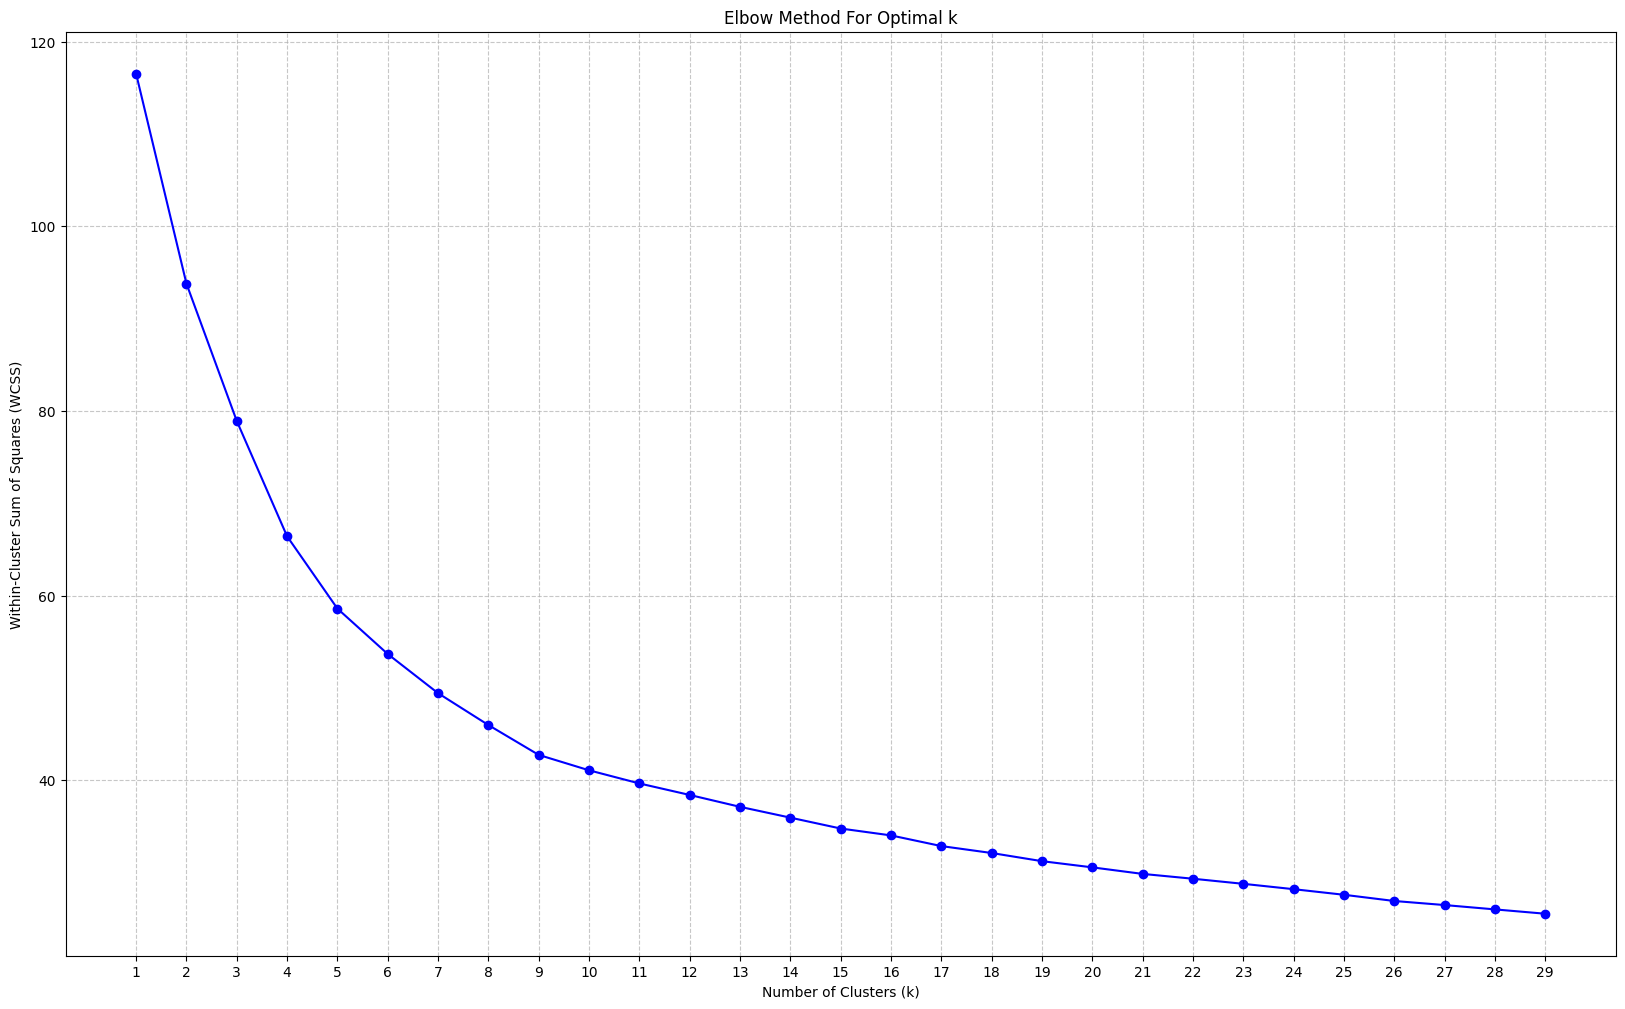

In [5]:
# Calculate WCSS ( Within-Cluster Sum of Squares ) for different values of k
wcss = []
k_range = range(1, 30) # Testing k=1 through k=100 

for k in k_range:
    # random_state ensures reproducible results
    # n_init=10 suppresses future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(20, 12))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')

plt.xticks(k_range) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Silhouette Score

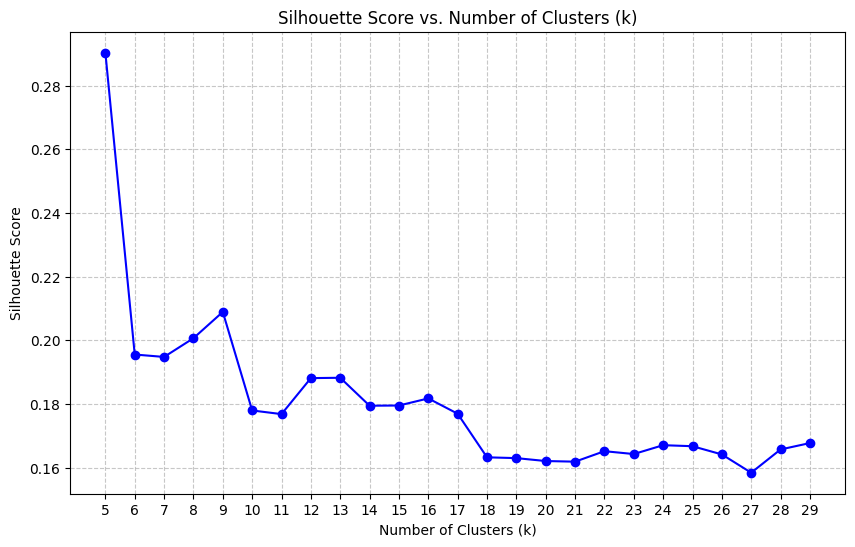

In [6]:
score_lst = []
k_range = range(5, 30) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(Features)
    labels = pd.Series(kmeans.labels_)
    norm_df["Cluster"] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

## Kmeans for 7 clusters

In [7]:
kmeans = KMeans(n_clusters = 7,random_state = 42, n_init="auto").fit(Features)
labels = pd.Series(kmeans.labels_)
norm_df["Cluster"] = labels
output(labels)

The labels:
 0       2
1       4
2       1
3       6
4       6
       ..
8063    2
8064    2
8065    4
8066    6
8067    6
Length: 8068, dtype: int32
Cluster Counts:
 2    2259
6    1838
1    1708
0    1026
3     480
5     431
4     326
Name: count, dtype: int64


In [8]:
# Check how many streets are in each of the 9 clusters
val_count_sorted = norm_df['Cluster'].value_counts().sort_index()
val_count_sorted

Cluster
0    1026
1    1708
2    2259
3     480
4     326
5     431
6    1838
Name: count, dtype: int64

In [9]:
# Define the outlier clusters we want to push to the end
outlier_clusters = singleton_labels = val_count_sorted[val_count_sorted == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(norm_df['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# The main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked as intended
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
norm_df['Cluster'] = norm_df['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6


In [10]:
# Df after clustering
norm_df

,Street_Name,Profile_1 (Street_and_Transportation_Pct),Profile_2 (Noise_Pct),Profile_3 (Other/Misc_LType_Pct),Profile_4 (Sanitation_and_Trash_Pct),Profile_5 (Street_and_Infrastructure_Pct),Profile_6 (Residential_and_Mixed_Use_Pct),Profile_7 (Weekend_Ratio),Profile_8 (Street_and_Transportation_Pct),Profile_9 (Night_Complaint_Pct),Cluster
0,1 AVENUE,0.005916,0.020719,0.021243,0.013985,0.009868,0.074331,0.053828,0.075523,0.053866,2
1,1 AVENUE LOOP,0.000000,0.000408,0.058636,0.000000,0.223096,0.000000,0.041397,0.000000,0.000006,4
2,1 COURT,0.018875,0.000383,0.025575,0.038693,0.027028,0.017134,0.063515,0.062851,0.000000,1
3,1 PLACE,0.026447,0.008818,0.023336,0.009325,0.023732,0.024262,0.051766,0.032914,0.025272,6
4,1 STREET,0.016914,0.017540,0.023827,0.018457,0.023822,0.038072,0.047565,0.046865,0.039396,6
...,...,...,...,...,...,...,...,...,...,...,...
8063,ZOE STREET,0.007548,0.007636,0.058740,0.023508,0.000000,0.105662,0.071403,0.037989,0.040101,2
8064,ZOLLER ROAD,0.000451,0.039976,0.081874,0.033093,0.010276,0.045273,0.068398,0.000000,0.087096,2
8065,ZOO BRIDGE,0.000000,0.000031,0.034636,0.000000,0.258601,0.000000,0.000000,0.000000,0.000000,4
8066,ZULETTE AVENUE,0.025767,0.003968,0.020702,0.021426,0.035753,0.007546,0.063687,0.042384,0.030571,6


In [11]:
# Street data with geo info
streets_projected

,full_street_name,geometry
0,AVENUE NORTH,"POLYGON ((994139.216 163416.286, 994143.124 16..."
1,HONE AVENUE,"POLYGON ((1023559.637 254630.271, 1023559.909 ..."
2,48 STREET,"POLYGON ((1011219.591 219044.016, 1011216.783 ..."
3,LAIGHT STREET,"POLYGON ((981020.607 202397.126, 981016.746 20..."
4,BROOK AVENUE,"POLYGON ((950481.675 142652.323, 950465.007 14..."
...,...,...
122255,CLOVE LAKE PATH,"POLYGON ((954037.12 164385.811, 954026.004 164..."
122256,ALLEY,"POLYGON ((1014506.033 175164.65, 1014378.255 1..."
122257,64 AV PEDESTRIAN OPAS,"POLYGON ((1027497.702 206882.915, 1027501.503 ..."
122258,ALLEY,"POLYGON ((1024699.173 202136.356, 1024647.443 ..."


In [12]:
# Extract the centroids from the fitted model
centroids = kmeans.cluster_centers_

# Convert to a DataFrame for readability
centroid_df = pd.DataFrame(centroids, columns=Features.columns)
centroid_df.index.name = 'Cluster'
# 1. Calculate the Global Means across your entire dataset
global_means = Features.mean()

def analyze_relative_personas(centroid_dataframe, global_averages, top_n=3):
    """
    Identifies distinct personas by finding features that are significantly
    higher than the global baseline (Relative Importance / Lift).
    """
    print(f"--- Top {top_n} Unique Defining Features per Cluster ---\n")
    
    # Calculate the relative importance (Cluster Mean / Global Mean)
    # Adding a tiny number (1e-9) prevents division by zero errors
    relative_importance = centroid_dataframe / (global_averages + 1e-9)
    
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the relative multipliers for this cluster
        cluster_multipliers = relative_importance.loc[cluster_id]
        
        # Sort by the highest multiplier to find what makes them unique
        top_features = cluster_multipliers.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id} Persona:")
        for feature, multiplier in top_features.items():
            
            # Grab the actual absolute value just for context
            actual_val = centroid_dataframe.loc[cluster_id, feature]
            
            # Print the feature, how many times the average it is, and the raw value
            print(f"  * {feature}: {multiplier:.1f}x the global average (Raw value: {actual_val:.4f})")
            
        print("-" * 50)

# Run the function
analyze_relative_personas(centroid_df, global_means, top_n=4)

--- Top 4 Unique Defining Features per Cluster ---

Cluster 0 Persona:
  * Profile_6 (Residential_and_Mixed_Use_Pct): 3.9x the global average (Raw value: 0.1661)
  * Profile_2 (Noise_Pct): 1.5x the global average (Raw value: 0.0178)
  * Profile_9 (Night_Complaint_Pct): 1.2x the global average (Raw value: 0.0516)
  * Profile_7 (Weekend_Ratio): 1.0x the global average (Raw value: 0.0597)
--------------------------------------------------
Cluster 1 Persona:
  * Profile_8 (Street_and_Transportation_Pct): 1.7x the global average (Raw value: 0.0919)
  * Profile_4 (Sanitation_and_Trash_Pct): 1.1x the global average (Raw value: 0.0354)
  * Profile_5 (Street_and_Infrastructure_Pct): 1.1x the global average (Raw value: 0.0292)
  * Profile_3 (Other/Misc_LType_Pct): 1.0x the global average (Raw value: 0.0236)
--------------------------------------------------
Cluster 2 Persona:
  * Profile_2 (Noise_Pct): 1.7x the global average (Raw value: 0.0205)
  * Profile_9 (Night_Complaint_Pct): 1.7x the glob

## Visualizations ( Maps )

In [ ]:
# ============================================================
# STEP 1 — Filter streets to those in our data
# ============================================================

streets_to_plot = streets_projected[
    streets_projected['full_street_name'].isin(norm_df['Street_Name'])
][['full_street_name', 'geometry']].copy()

streets_to_plot = streets_to_plot.dissolve(by='full_street_name').reset_index()

# ============================================================
# STEP 2 — Merge cluster info
# ============================================================

streets_to_plot = streets_to_plot.merge(
    norm_df[['Street_Name', 'Cluster']],
    left_on='full_street_name',
    right_on='Street_Name',
    how='left'
)

streets_to_plot['Cluster'] = 'Cluster ' + streets_to_plot['Cluster'].astype(str)

# ============================================================
# STEP 3 — Reproject to 4326
# ============================================================

streets_to_plot = streets_to_plot.to_crs(epsg=4326)

print(f"Rendering {len(streets_to_plot):,} streets across {streets_to_plot['Cluster'].nunique()} clusters...")

# ============================================================
# STEP 4 — Build NYC outline from nyc_map (zip code polygons)
# ============================================================

boroughs = nyc_map[['geometry']].copy()  
boroughs['region'] = 'NYC'
boroughs = boroughs.dissolve(by='region').reset_index()  # merge all zips into one outline
boroughs = boroughs.to_crs(epsg=4326)

# ============================================================
# STEP 5 — Kepler.gl config
# ============================================================

kepler_config = {
    'version': 'v1',
    'config': {
        'visState': {
            'layers': [
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Boroughs',
                        'label': 'NYC Boroughs',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':       0.0,    # no fill, outline only
                            'strokeOpacity': 0.9,
                            'thickness':     1.5,
                            'stroked':       True,
                            'filled':        False,
                            'strokeColor':   [255, 255, 255],
                        },
                    },
                },
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Streets by Cluster',
                        'label': 'NYC Streets by Cluster',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':        0.85,
                            'strokeOpacity':  0.8,
                            'thickness':      0.5,
                            'stroked':        True,
                            'filled':         True,
                            'enable3d':       False,
                            'colorRange': {
                                'name':     'ColorBrewer Set1-9',
                                'type':     'qualitative',
                                'category': 'ColorBrewer',
                                'colors':   [
                                    '#e41a1c','#377eb8','#4daf4a',
                                    '#984ea3','#ff7f00','#ffff33',
                                    '#a65628','#f781bf','#999999'
                                ]
                            },
                        },
                    },
                    'visualChannels': {
                        'colorField': {
                            'name': 'Cluster',
                            'type': 'string'
                        },
                        'colorScale': 'ordinal',
                    }
                },
            ]
        },
        'mapState': {
            'latitude':  40.73,
            'longitude': -73.93,
            'zoom':      10
        },
        'mapStyle': {
            'styleType': 'dark',
            'visibleLayerGroups': {
                'label':    True,
                'road':     True,
                'border':   True,
                'building': False,
                'water':    True,
                'land':     True,
            }
        }
    }
}

# ============================================================
# STEP 6 — Render
# ============================================================

kepler_map = KeplerGl(height=750, config=kepler_config)

# Outline added first so it renders underneath
kepler_map.add_data(
    data=boroughs[['region', 'geometry']],
    name='NYC Boroughs'
)

kepler_map.add_data(
    data=streets_to_plot[['full_street_name', 'Cluster', 'geometry']],
    name='NYC Streets by Cluster'
)

kepler_map